# Caravan quickstart — an open GRDC hydrograph

[Caravan](https://github.com/kratzert/Caravan) is a community dataset of large-sample hydrology: per catchment, a daily **streamflow** series, **ERA5-Land** meteorological forcing, static attributes, and a basin polygon — all standardised onto one schema.

This notebook does two things:

1. pulls a real **GRDC** hydrograph — the openly-licensed route to Global Runoff Data Centre discharge, which the raw GRDC portal does not offer; and
2. shows that it costs about **3 MB**, not the **8.84 GB** the archive weighs.

No credentials are needed. Everything here is anonymous static HTTP.

## What the catalog knows

Each row pins a **specific Zenodo version record** rather than the moving concept DOI, so this notebook fetches the same bytes next year as it does today.

In [1]:
import pandas as pd

from earthlens.caravan import Catalog

catalog = Catalog()
rows = []
for key in sorted(catalog.extensions):
    extension = catalog.get_extension(key)
    release = extension.resolve_version()
    archive = release.file_for("csv")
    rows.append(
        {
            "dataset=": key,
            "catchments": release.n_catchments,
            "period": release.data_period,
            "record": archive.record,
            "GB": round(archive.size / 1e9, 2),
            "range-readable": archive.is_range_readable,
        }
    )
pd.DataFrame(rows)

2026-08-01 20:06:24 | INFO | pyramids.base.config | Logging is configured.


,dataset=,catchments,period,record,GB,range-readable
0,base,16300,"(1950, 2023)",15530022,28.95,False
1,denmark,308,"(1981, 2020)",15200118,0.52,True
2,germany,1887,"(1951, 2020)",14755229,6.09,True
3,grdc,5356,"(1950, 2023)",15349031,8.84,True
4,israel,95,"(1950, 2024)",15181680,0.29,True


`base` is the only row that is not range-readable — it ships as a single `.tar.gz`, which has no directory to seek into. Every other extension is a ZIP, and a ZIP can be read in place.

## Fetch one catchment

`GRDC_1159100` is the Orange River at Vioolsdrif, South Africa — a 786,000 km² catchment with a record running from 1950. Note the **uppercase** `GRDC_` prefix: every other source uses lowercase (`camelsdk_100006`, `il_12130`), and this is the single most common id mistake.

In [2]:
from earthlens.core import EarthLens

facade = EarthLens(
    "grdc-caravan",
    variables=["streamflow", "total_precipitation", "temperature_2m_mean"],
    start="2000-01-01",
    end="2005-12-31",
    lat_lim=[-90, 90],
    lon_lim=[-180, 180],
    gauge_ids=["GRDC_1159100"],
    path="outputs",
)
flow = facade.download()
flow.head()

2026-08-01 20:06:29.582 | DEBUG    | earthlens.caravan._helpers:open_remote_zip:362 - caravan: indexed 5367 members of caravan/grdc in 4 range requests (0.81 MB)


2026-08-01 20:06:29.672 | INFO     | earthlens.caravan.backend:_search:461 - caravan grdc: 1 catchment(s) selected from GRDC_Caravan_extension_csv.zip


2026-08-01 20:06:31.708 | INFO     | earthlens.caravan.backend:_log_transfer:580 - caravan grdc: 6 range request(s), 2.91 MB transferred (archive is 8.8 GB)


2026-08-01 20:06:31.720 | INFO     | earthlens.caravan.backend:download:762 - caravan grdc: 2192 row(s) written to C:\python-environments\worktrees\earthlens\caravan\docs\examples\caravan\outputs\caravan_grdc_0-6.csv


,gauge_id,date,streamflow,total_precipitation_sum,temperature_2m_mean
0,GRDC_1159100,2000-01-01,0.02,4.53,20.53
1,GRDC_1159100,2000-01-02,0.02,2.35,20.27
2,GRDC_1159100,2000-01-03,0.02,1.72,21.81
3,GRDC_1159100,2000-01-04,0.02,5.22,22.33
4,GRDC_1159100,2000-01-05,0.02,8.98,21.80


## What that actually cost

The archive is 8.84 GB. The backend read its file directory from the tail, then inflated one member — nothing was written to disk and nothing else transferred.

In [3]:
backend = facade.datasource
requests_made, megabytes = backend._open_archive().transfer_stats
archive_gb = backend.archive_file.size / 1e9

print(f"archive        : {archive_gb:.2f} GB")
print(f"transferred    : {megabytes:.2f} MB in {requests_made} range requests")
print(f"saving         : {archive_gb * 1000 / megabytes:.0f}x less than downloading it")
print(f"rows returned  : {len(flow)}")

archive        : 8.84 GB
transferred    : 2.91 MB in 6 range requests
saving         : 3039x less than downloading it
rows returned  : 2192


## Plot the hydrograph

`streamflow` is **mm/day** — discharge normalised by catchment area, so it is a depth rather than m³/s. Gaps come back as `NaN` and are deliberately left in place: they are genuine missing observations, not fetch failures.

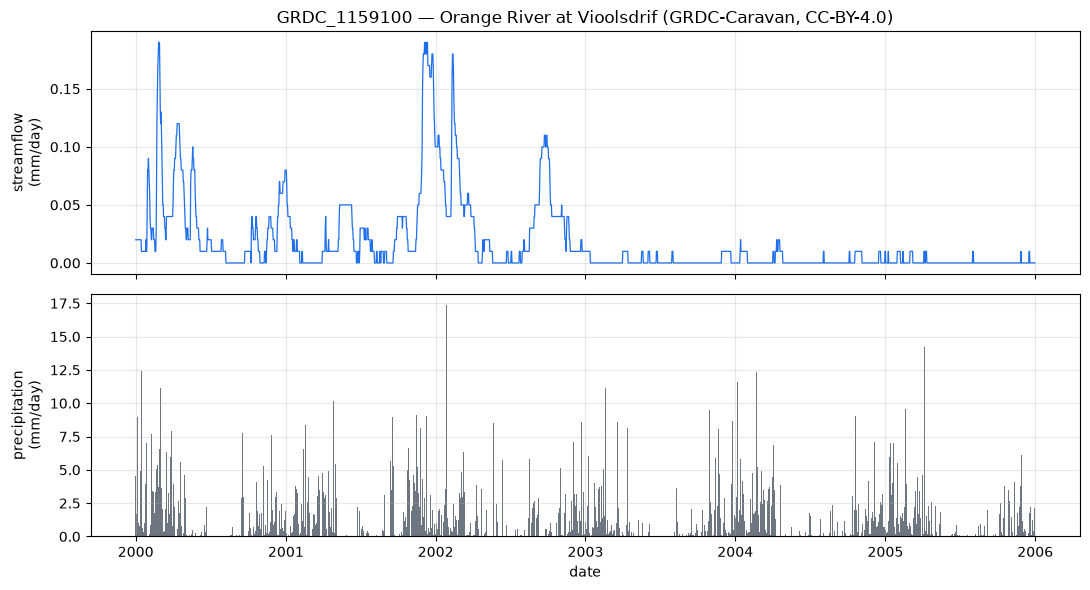

missing streamflow days: 0.0%


In [4]:
import matplotlib.pyplot as plt

series = flow.set_index("date")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(series.index, series["streamflow"], lw=0.9, color="#1f6feb")
axes[0].set_ylabel("streamflow\n(mm/day)")
axes[0].set_title("GRDC_1159100 — Orange River at Vioolsdrif (GRDC-Caravan, CC-BY-4.0)")
axes[0].grid(alpha=0.3)

axes[1].bar(series.index, series["total_precipitation_sum"], width=1.0, color="#6e7781")
axes[1].set_ylabel("precipitation\n(mm/day)")
axes[1].set_xlabel("date")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

missing = series["streamflow"].isna().mean()
print(f"missing streamflow days: {missing:.1%}")

## Select by country instead of by id

Bounding boxes and `country=` are resolved against the archive's own gauge coordinates. `country=` matches the **full English name** stored in the archive (`"Denmark"`), not an ISO2 code.

`limit=` genuinely stops the work for a ZIP: catchments past the cap are never read.

In [5]:
danish = EarthLens(
    "caravan",
    dataset="denmark",
    variables=["streamflow"],
    start="2015-01-01",
    end="2015-12-31",
    lat_lim=[-90, 90],
    lon_lim=[-180, 180],
    country="Denmark",
    path="outputs",
).download(limit=1095)

print(f"{danish['gauge_id'].nunique()} catchments, {len(danish)} catchment-days")
danish.groupby("gauge_id")["streamflow"].describe().head()

2026-08-01 20:06:36.956 | DEBUG    | earthlens.caravan._helpers:open_remote_zip:362 - caravan: indexed 625 members of caravan/denmark in 3 range requests (0.08 MB)


2026-08-01 20:06:38.188 | INFO     | earthlens.caravan.backend:_search:461 - caravan denmark: 308 catchment(s) selected from Caravan_extension_DK.zip


2026-08-01 20:06:41.255 | INFO     | earthlens.caravan.backend:_log_transfer:580 - caravan denmark: 7 range request(s), 4.27 MB transferred (archive is 0.5 GB)


2026-08-01 20:06:41.261 | INFO     | earthlens.caravan.backend:download:762 - caravan denmark: 1095 row(s) written to C:\python-environments\worktrees\earthlens\caravan\docs\examples\caravan\outputs\caravan_denmark_2025-04-11.csv


3 catchments, 1095 catchment-days


,count,mean,std,min,25%,50%,75%,max
gauge_id,,,,,,,,
camelsdk_100006,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
camelsdk_100009,365.0,1.264466,0.557625,0.56,0.91,1.07,1.47,4.54
camelsdk_100010,365.0,0.864329,0.327819,0.41,0.61,0.79,1.06,2.40


## Compare the annual regimes

One reason Caravan exists: catchments from different national datasets share a schema, so they can be compared without per-source plumbing.

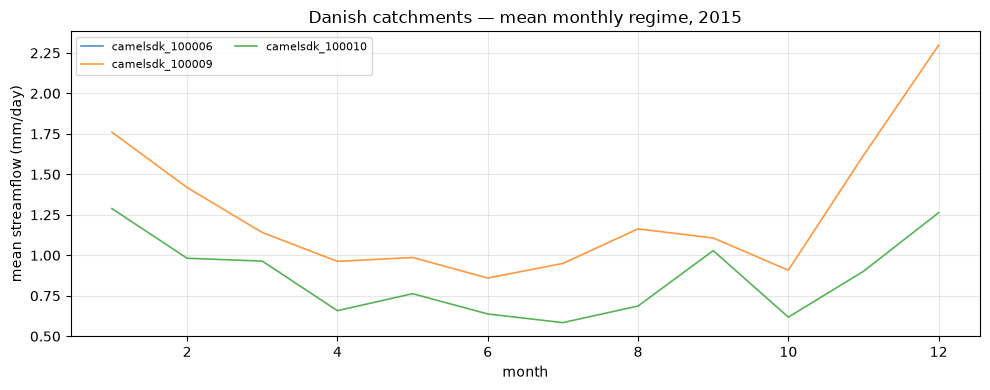

In [6]:
monthly = (
    danish.assign(month=danish["date"].dt.month)
    .groupby(["gauge_id", "month"])["streamflow"]
    .mean()
    .unstack("month")
)

fig, ax = plt.subplots(figsize=(10, 4))
for gauge_id, row in monthly.iterrows():
    ax.plot(row.index, row.values, lw=1.2, alpha=0.8, label=gauge_id)
ax.set_xlabel("month")
ax.set_ylabel("mean streamflow (mm/day)")
ax.set_title("Danish catchments — mean monthly regime, 2015")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Two things to remember

**This is an archive, not a feed.** GRDC itself is historical — national services submit at irregular, often multi-year lags — and Caravan republishes as snapshots every 4–12 months. The GRDC series above ends in **May 2023**. For current discharge use `earthlens.usgs_water` (US near-real-time) or GloFAS via `earthlens.ecmwf`.

**This is the open GRDC subset, not the whole database.** GRDC-Caravan covers only the stations whose national services permit redistribution. The rest remain portal-only.

Everything here is **CC-BY-4.0**: cite Caravan (Kratzert et al., *Sci Data* 10, 61, 2023), the GRDC-Caravan extension, and the source datasets you used.

In [7]:
print(catalog.get_extension("grdc").attribution)

Faerber, C., Bertola, M., et al. GRDC-Caravan. Data provided by the Global Runoff Data Centre (GRDC), Koblenz, Germany. Per-country upstream licences are listed in `licenses/grdc/LicensesCaravan.xlsx` inside the archive.
